# **PRE — EDA**

在开始构建模型之前，我们先对数据进行初步探索，了解其分布、缺失情况以及文本特征。这有助于后续的特征工程和模型选择

In [1]:
# ==============================================
# 0. 导入通用库（如果之前没有导入）
# ==============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 设置绘图风格
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# ==============================================
# 1. 加载数据
# ==============================================
train = pd.read_csv('/kaggle/input/competitions/nlp-getting-started/train.csv')
test = pd.read_csv('/kaggle/input/competitions/nlp-getting-started/test.csv')

print("训练集形状:", train.shape)
print("测试集形状:", test.shape)

# 查看前几行
train.head()

训练集形状: (7613, 5)
测试集形状: (3263, 4)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


观察目标变量分布：可以看到这是一个相对平衡的二分类问题（约 57% 非灾难，43% 灾难），因此不需要特别处理类别不平衡。

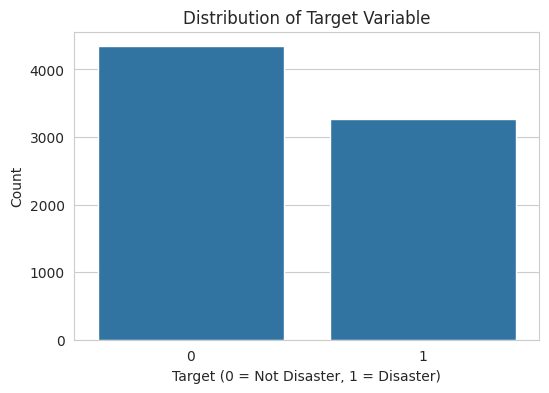

非灾难推文占比: 57.03%
灾难推文占比: 42.97%


In [2]:
# 目标变量（target）的分布
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=train)
plt.title('Distribution of Target Variable')
plt.xlabel('Target (0 = Not Disaster, 1 = Disaster)')
plt.ylabel('Count')
plt.show()

# 打印比例
target_counts = train['target'].value_counts(normalize=True) * 100
print("非灾难推文占比: {:.2f}%".format(target_counts[0]))
print("灾难推文占比: {:.2f}%".format(target_counts[1]))

缺失值分析：keyword 和 location 存在较多缺失，后续可以将其作为特征或直接舍弃

In [3]:
# 检查训练集和测试集的缺失值
print("训练集缺失值：")
print(train.isnull().sum())
print("\n测试集缺失值：")
print(test.isnull().sum())

训练集缺失值：
id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

测试集缺失值：
id             0
keyword       26
location    1105
text           0
dtype: int64


文本长度分析：大多数推文字符数在 100 到 140 之间，单词数在 15 到 20 左右，因此设置 BERT 的最大长度 MAX_LEN=128 是合适的。

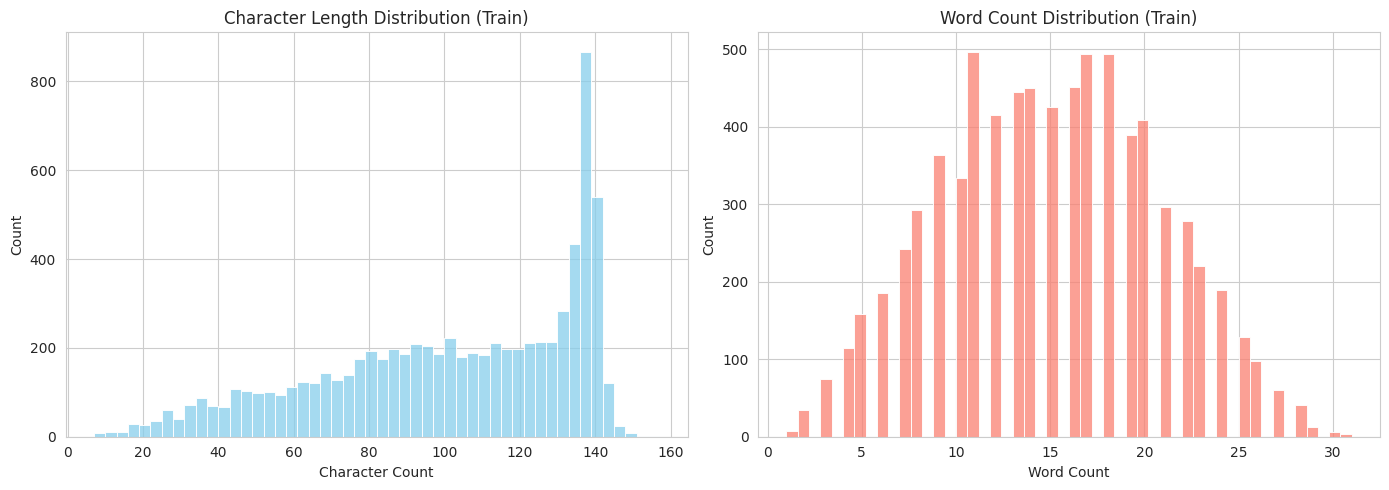

字符数统计：
count    7613.000000
mean      101.037436
std        33.781325
min         7.000000
25%        78.000000
50%       107.000000
75%       133.000000
max       157.000000
Name: char_length, dtype: float64

单词数统计：
count    7613.000000
mean       14.903586
std         5.732604
min         1.000000
25%        11.000000
50%        15.000000
75%        19.000000
max        31.000000
Name: word_count, dtype: float64


In [4]:
# 计算每条推文的字符数和单词数
train['char_length'] = train['text'].astype(str).apply(len)
train['word_count'] = train['text'].astype(str).apply(lambda x: len(x.split()))

test['char_length'] = test['text'].astype(str).apply(len)
test['word_count'] = test['text'].astype(str).apply(lambda x: len(x.split()))

# 绘制训练集文本长度分布
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train['char_length'], bins=50, ax=axes[0], color='skyblue')
axes[0].set_title('Character Length Distribution (Train)')
axes[0].set_xlabel('Character Count')

sns.histplot(train['word_count'], bins=50, ax=axes[1], color='salmon')
axes[1].set_title('Word Count Distribution (Train)')
axes[1].set_xlabel('Word Count')

plt.tight_layout()
plt.show()

# 打印统计信息
print("字符数统计：")
print(train['char_length'].describe())
print("\n单词数统计：")
print(train['word_count'].describe())

关键词分析：可以看出某些关键词（如 "debris"、"wreckage"）具有很强的灾难指示性，而另一些（如 "love"、"smile"）则相反。这个信息可以作为特征加入模型。

/tmp/ipykernel_58/2255850910.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_keywords.values, y=top_keywords.index, palette='viridis')


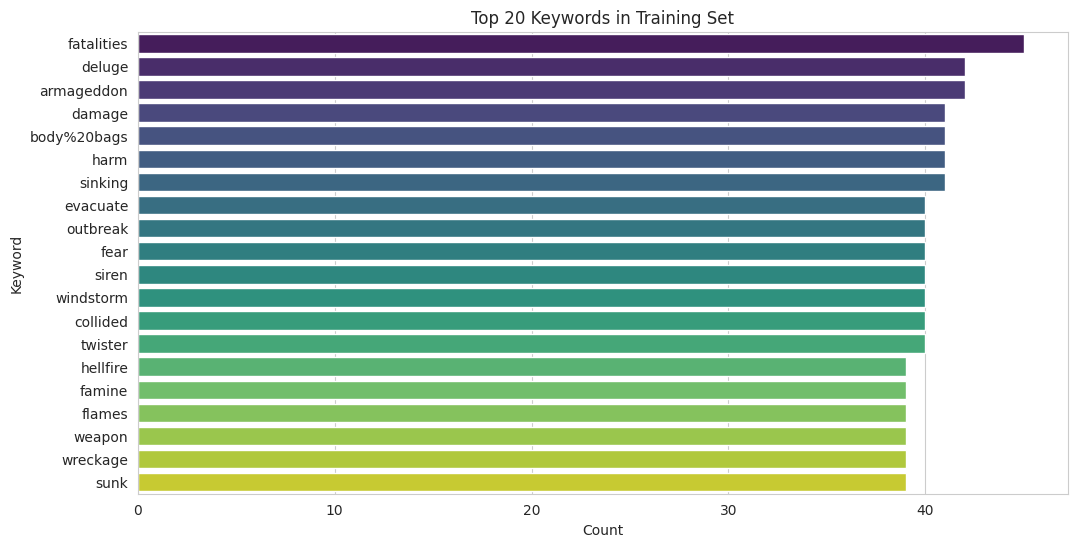

/tmp/ipykernel_58/2255850910.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=keyword_target_mean.head(20), x='mean', y='keyword', palette='rocket')


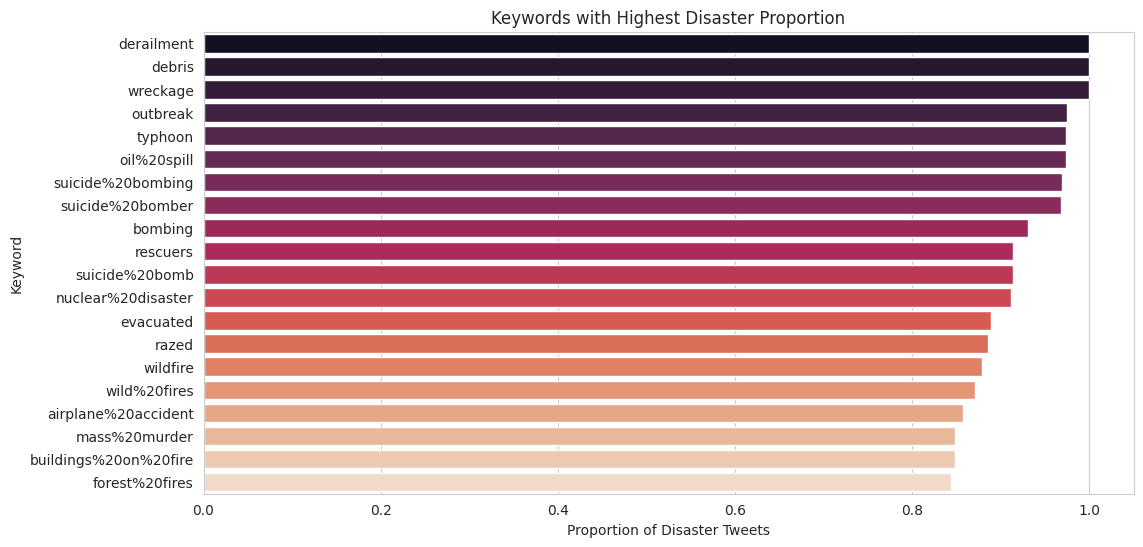

In [5]:
# 查看关键词的分布（训练集）
plt.figure(figsize=(12, 6))
top_keywords = train['keyword'].value_counts().head(20)
sns.barplot(x=top_keywords.values, y=top_keywords.index, palette='viridis')
plt.title('Top 20 Keywords in Training Set')
plt.xlabel('Count')
plt.ylabel('Keyword')
plt.show()

# 观察关键词与目标变量的关系
# 按关键词计算灾难比例（仅取出现次数较多的关键词）
keyword_target_mean = train.groupby('keyword')['target'].agg(['mean', 'count']).reset_index()
keyword_target_mean = keyword_target_mean[keyword_target_mean['count'] > 10]  # 过滤低频
keyword_target_mean = keyword_target_mean.sort_values('mean', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=keyword_target_mean.head(20), x='mean', y='keyword', palette='rocket')
plt.title('Keywords with Highest Disaster Proportion')
plt.xlabel('Proportion of Disaster Tweets')
plt.ylabel('Keyword')
plt.show()

词频分析：通过词云可以直观地看到两类文本的主题差异，例如灾难推文中常出现 "fire"、"death"、"storm" 等词。

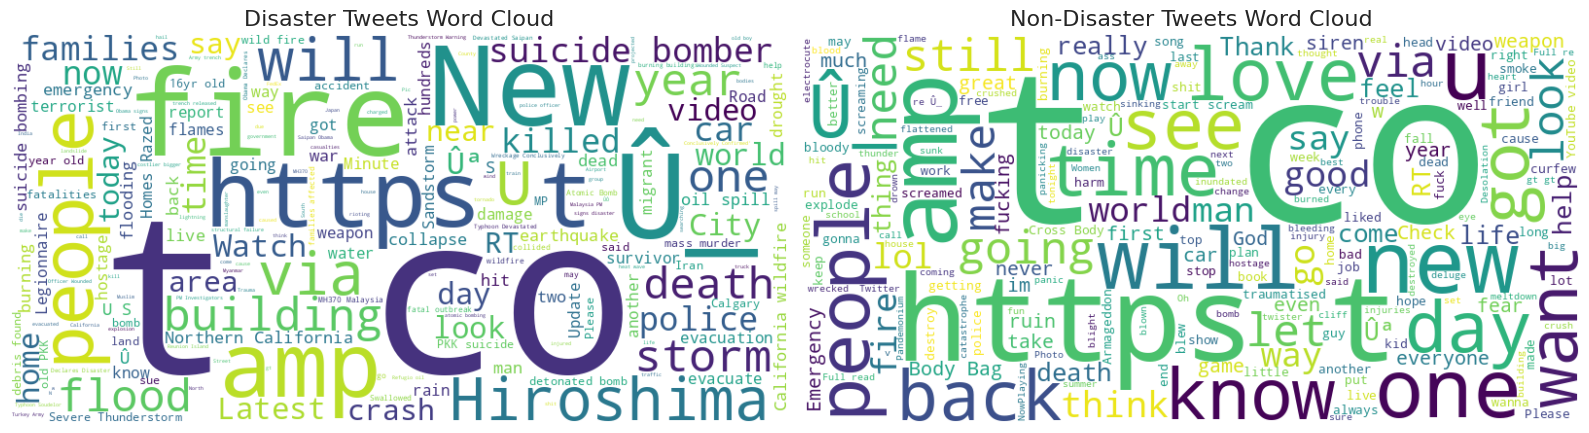

In [6]:
from collections import Counter
from wordcloud import WordCloud

# 分别提取灾难和非灾难推文的文本
disaster_text = ' '.join(train[train['target']==1]['text'].astype(str).tolist())
non_disaster_text = ' '.join(train[train['target']==0]['text'].astype(str).tolist())

# 生成词云
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
wc_dis = WordCloud(width=800, height=400, background_color='white').generate(disaster_text)
wc_non = WordCloud(width=800, height=400, background_color='white').generate(non_disaster_text)

axes[0].imshow(wc_dis, interpolation='bilinear')
axes[0].set_title('Disaster Tweets Word Cloud', fontsize=16)
axes[0].axis('off')

axes[1].imshow(wc_non, interpolation='bilinear')
axes[1].set_title('Non-Disaster Tweets Word Cloud', fontsize=16)
axes[1].axis('off')

plt.tight_layout()
plt.show()

# **Disaster Tweets NLP - Bert微调**

In [25]:
# import pandas as pd
# import numpy as np
# import re
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.linear_model import LogisticRegression
# from sklearn.model_selection import cross_val_predict, StratifiedKFold
# from sklearn.metrics import f1_score, precision_recall_curve
# import matplotlib.pyplot as plt

# # 1. 加载数据
# train = pd.read_csv('/kaggle/input/competitions/nlp-getting-started/train.csv')
# test = pd.read_csv('/kaggle/input/competitions/nlp-getting-started/test.csv')
# submission = pd.read_csv('/kaggle/input/competitions/nlp-getting-started/sample_submission.csv')

# print("训练集形状:", train.shape)
# print("测试集形状:", test.shape)
# print(train.head())

# # 2. 简单的文本清洗函数
# def clean_text(text):
#     """
#     清洗文本：转为小写、去除URL、HTML标签、标点、多余空格
#     """
#     if not isinstance(text, str):
#         text = ""
#     text = text.lower()
#     text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)  # 去除URL
#     text = re.sub(r'<.*?>', '', text)          # 去除HTML标签
#     text = re.sub(r'[^a-zA-Z\s]', '', text)    # 只保留字母和空格
#     text = re.sub(r'\s+', ' ', text).strip()   # 合并多个空格
#     return text

# # 应用清洗
# train['clean_text'] = train['text'].apply(clean_text)
# test['clean_text'] = test['text'].apply(clean_text)

# # 3. TF-IDF 特征提取
# # 使用单词和二元词组，限制最大特征数
# tfidf = TfidfVectorizer(
#     max_features=10000,
#     ngram_range=(1, 2),
#     stop_words='english'
# )

# X_train = tfidf.fit_transform(train['clean_text'])
# X_test = tfidf.transform(test['clean_text'])
# y_train = train['target'].values

# print("TF-IDF 训练集维度:", X_train.shape)
# print("TF-IDF 测试集维度:", X_test.shape)

# # 4. 训练模型（使用交叉验证评估）
# model = LogisticRegression(max_iter=1000, C=1.0, solver='liblinear')

# # 使用分层 K 折获得验证集上的预测概率
# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# val_preds = cross_val_predict(model, X_train, y_train, cv=cv, method='predict_proba')[:, 1]

# # 5. 阈值调优（基于验证集）
# precision, recall, thresholds = precision_recall_curve(y_train, val_preds)
# f1_scores = 2 * precision * recall / (precision + recall + 1e-9)
# best_idx = np.argmax(f1_scores)
# best_threshold = thresholds[best_idx]
# best_f1 = f1_scores[best_idx]

# print(f"最佳阈值: {best_threshold:.4f}")
# print(f"最佳 F1 (交叉验证): {best_f1:.4f}")

# # 可以画出 P-R 曲线查看
# plt.figure(figsize=(6,5))
# plt.plot(recall, precision, marker='.')
# plt.xlabel('Recall')
# plt.ylabel('Precision')
# plt.title('Precision-Recall Curve')
# plt.grid(True)
# plt.show()

# # 6. 重新在全部训练数据上训练模型
# model.fit(X_train, y_train)

# # 7. 预测测试集并应用最佳阈值
# test_probs = model.predict_proba(X_test)[:, 1]
# test_preds = (test_probs >= best_threshold).astype(int)

# # 8. 生成提交文件
# submission['target'] = test_preds
# submission.to_csv('submission.csv', index=False)
# print("提交文件已保存为 submission.csv")
# print(submission['target'].value_counts())

# **1-环境检查**

In [26]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_recall_curve
import random
import re
import matplotlib.pyplot as plt

# 设置随机种子
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
set_seed(42)

# 检查 GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

# 检查可用 GPU 数量
num_gpus = torch.cuda.device_count()
print(f"Number of GPUs available: {num_gpus}")

Using device: cuda
Number of GPUs available: 2


# **2-数据加载与清洗**

In [27]:
# 加载数据
train = pd.read_csv('/kaggle/input/competitions/nlp-getting-started/train.csv')
test = pd.read_csv('/kaggle/input/competitions/nlp-getting-started/test.csv')

def basic_clean(text):
    if not isinstance(text, str):
        text = ""
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)  # 移除URL
    text = re.sub(r'<.*?>', '', text)                     # 移除HTML标签
    text = re.sub(r'@\w+', '', text)                      # 可选：移除@提及
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train['text'] = train['text'].apply(basic_clean)
test['text'] = test['text'].apply(basic_clean)

# 训练集-验证集划分
X = train['text'].values
y = train['target'].values

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

# **3-构建 PyTorch Dataset 和 DataLoader**

使用 HuggingFace 的 BertTokenizer 将文本转换为模型需要的输入格式：**（input_ids, attention_mask）**

训练时的每个batch包含三个键：`input_ids`、`attention_mask` 和 `labels`。下面用具体示例说明它们长什么样。

---

1. 数据从何而来？

`TweetDataset` 的 `__getitem__` 方法负责将一条原始文本转换成模型需要的格式：

假设我们设置 `MAX_LEN = 8`（为了演示，实际常用 128）。有两条推文：

- 推文 A: `"Fire in the city!"`
- 推文 B: `"I love this song"`

它们的标签分别为 `1`（灾难）和 `0`（非灾难）。

---

2. tokenizer 的处理过程

第一步：分词并添加特殊符号
- 推文 A → `['[CLS]', 'fire', 'in', 'the', 'city', '!', '[SEP]']`
- 推文 B → `['[CLS]', 'i', 'love', 'this', 'song', '[SEP]']`

第二步：将每个 token 映射为词汇表中的 ID（整数）
假设词汇表中：
- `[CLS]` → 101
- `[SEP]` → 102
- `fire` → 2222
- `in` → 1999
- `the` → 2001
- `city` → 2223
- `!` → 999
- `i` → 1001
- `love` → 1002
- `this` → 1003
- `song` → 1004

则：
- 推文 A 的 ID 序列：`[101, 2222, 1999, 2001, 2223, 999, 102]`
- 推文 B 的 ID 序列：`[101, 1001, 1002, 1003, 1004, 102]`

第三步：填充到固定长度 `MAX_LEN=8`
- 推文 A 长度为 7，需要在末尾补 1 个 `[PAD]` token（ID 为 0）
- 推文 B 长度为 6，需要在末尾补 2 个 `[PAD]` token

填充后：
- 推文 A：`[101, 2222, 1999, 2001, 2223, 999, 102, 0]`
- 推文 B：`[101, 1001, 1002, 1003, 1004, 102, 0, 0]`

第四步：生成 attention mask
标记哪些位置是真实 token（1），哪些是填充的 `[PAD]`（0）：
- 推文 A：`[1, 1, 1, 1, 1, 1, 1, 0]`
- 推文 B：`[1, 1, 1, 1, 1, 1, 0, 0]`

---

3. DataLoader 中一个 batch 的实际内容

`DataLoader` 会将多条样本堆叠成一个大张量。假设 `batch_size=2`（即上面两条推文组成一个 batch），则：

- **`input_ids`**：形状 `(2, 8)` 的整数张量  
  ```
  tensor([[ 101, 2222, 1999, 2001, 2223,  999,  102,    0],
          [ 101, 1001, 1002, 1003, 1004,  102,    0,    0]])
  ```

- **`attention_mask`**：形状 `(2, 8)` 的二值张量  
  ```
  tensor([[1, 1, 1, 1, 1, 1, 1, 0],
          [1, 1, 1, 1, 1, 1, 0, 0]])
  ```

- **`labels`**：形状 `(2,)` 的整数张量  
  ```
  tensor([1, 0])
  ```

---

4. 这些数据在模型中如何使用？

- `input_ids` 和 `attention_mask` 一起输入 BERT 模型。  
  BERT 内部会对 `input_ids` 中的每个 token 查找对应的嵌入向量，并根据 `attention_mask` 忽略填充位置（不参与注意力计算）。  
- `labels` 用于计算交叉熵损失（当训练时传入 `labels` 参数，模型会自动计算损失）。  
  模型输出 `logits`（形状 `(batch_size, 2)`），然后与 `labels` 比较得到损失。

---


In [28]:
# 选择预训练模型
MODEL_NAME = 'bert-base-uncased'
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

MAX_LEN = 128  # 最大序列长度，多数推文长度小于128，可根据数据分布调整

class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        # 直接调用 tokenizer 对象，它会自动处理特殊 token、padding、truncation 等
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,      # 添加 [CLS] 和 [SEP]
            max_length=self.max_len,      # 最大序列长度
            padding='max_length',         # 填充到 max_length
            truncation=True,              # 超长截断
            return_attention_mask=True,   # 返回注意力掩码
            return_tensors='pt'           # 返回 PyTorch 张量
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# 创建数据集 embedding过程
train_dataset = TweetDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset = TweetDataset(X_val, y_val, tokenizer, MAX_LEN)

# 创建 DataLoader
BATCH_SIZE = 32  # 根据 GPU 内存调整，通常 16/32 都可
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# **4-加载预训练模型并设置优化器**

使用 **BertForSequenceClassification**，它是一个通用的序列分类模型，二分类任务时设置 num_labels=2

`BertForSequenceClassification` 是在 HuggingFace Transformers 库中预定义好的一个类。它继承自 `BertPreTrainedModel`，内部结构可以简单表示为：

```
BERT 主干（BertModel）
    ↓
[CLS] 对应的隐藏状态（或池化输出）
    ↓
Dropout 层
    ↓
线性分类头（nn.Linear(hidden_size, num_labels)）
    ↓
输出 logits（形状 batch_size × num_labels）
```

当你调用 `BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)` 时，它会：
- 加载预训练的 BERT 权重（包括所有 Transformer 层）
- 根据 `num_labels=2` 自动添加一个未初始化的分类头（线性层），输出维度为 2
- 微调时训练学习的只有***线性分类层***的权重，该权重是随机初始化的

直接调用该模型的好处是**不需要**自己手动添加线性层，这个类已经封装好了

除此之外，HuggingFace 为不同任务提供了许多预定义的模型类，例如：

| 任务类型 | 模型类 | 说明 |
|---------|--------|------|
| 序列分类（二分类/多分类） | `BertForSequenceClassification` | 就是我们正在用的 |
| 标记分类（如命名实体识别） | `BertForTokenClassification` | 输出每个 token 的类别 |
| 问答（抽取式） | `BertForQuestionAnswering` | 输出答案的起始和结束位置 |
| 掩码语言模型 | `BertForMaskedLM` | 预测被 mask 掉的 token |
| 下一句预测 | `BertForNextSentencePrediction` | 判断两句话是否连续 |
| 多选 | `BertForMultipleChoice` | 从多个选项中选择一个 |

这些类都基于同一个 BERT 主干，只是在顶部添加了不同的“任务头”。

In [29]:
# BertForSequenceClassification 是 BERT 用于分类任务的便捷封装，自动包含了一个线性分类头
model = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

# 如果有多块 GPU，用 DataParallel 包装模型
if num_gpus > 1:
    model = nn.DataParallel(model)
model.to(device)  # device 仍然是 'cuda:0' 或 'cuda'

# 优化器
LEARNING_RATE = 2e-5  # 学习率 推荐范围 1e-5 ~ 5e-5
EPOCHS = 3            # 通常 2~4 个 epoch 足够
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

# 学习率调度器（线性预热 + 线性衰减）
total_steps = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)  # 10% 的步数用于预热
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

# 损失函数（模型内部已包含，但可以自定义）
criterion = nn.CrossEntropyLoss()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# **5-定义训练函数与评估模型**

训练过程采用 **`scheduler`（学习率调度器）**  
   学习率调度用于在训练过程中动态调整学习率。通常采用“预热”（warmup）和“线性衰减”策略：
   - **预热阶段**：训练开始时，学习率从很小的值逐渐增加到设定的初始学习率，有助于稳定训练，避免一开始梯度太大导致参数剧烈更新。
   - **衰减阶段**：随着训练的进行，学习率线性下降，使模型在后期更精细地收敛。
   - `scheduler.step()` 在每个 batch 之后被调用，它会根据当前的训练步数更新优化器中的学习率。

In [30]:
def train_epoch(model, data_loader, optimizer, scheduler, device):
    """
    训练一个 epoch。

    参数:
    
        model: BERT 分类模型
        data_loader: 训练数据的 DataLoader，每次返回一个 batch
        optimizer: 优化器（AdamW）
        scheduler: 学习率调度器（用于动态调整学习率）
        device: 设备（'cuda' 或 'cpu'）

    返回:
        accuracy: 当前 epoch 训练集的准确率
        avg_loss: 当前 epoch 训练集的平均损失
    """
    model.train()  # 将模型设置为训练模式（启用 dropout、batch norm 等）
    losses = []                # 用于记录每个 batch 的损失
    correct_predictions = 0    # 统计预测正确的样本数
    total_predictions = 0      # 统计总样本数

    for batch in data_loader:
        # batch 是一个字典，包含 input_ids, attention_mask, labels
        # 将数据从 CPU 转移到 GPU（如果 device 是 'cuda'），以加速计算
        input_ids = batch['input_ids'].to(device)          # 输入 token 的 ID 序列，形状 (batch_size, max_len)
        attention_mask = batch['attention_mask'].to(device) # 注意力掩码，标记哪些位置是真实 token（1）哪些是 padding（0）
        labels = batch['labels'].to(device)                # 真实标签，形状 (batch_size,)

        # 清空上一次迭代的梯度（因为 PyTorch 默认会累积梯度）
        optimizer.zero_grad()

        # 前向传播：将数据输入模型，得到输出
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels          # 传入 labels 会使模型内部直接计算交叉熵损失
        )

        loss = outputs.loss        # 模型的损失值（交叉熵损失）
        loss = loss.mean()   # 多 GPU时，需要将多个GPU返回的向量损失平均为标量，单GPU同样适用
        logits = outputs.logits    # 模型的原始输出（未经过 softmax），形状 (batch_size, 2)

        # 从 logits 中获取预测类别：找到每行最大值的索引（0 或 1）
        _, preds = torch.max(logits, dim=1)  # preds 形状 (batch_size,)，每个元素是预测的类别

        # 反向传播：计算梯度
        loss.backward()

        # 梯度裁剪：限制梯度的大小，防止梯度爆炸（常用于 RNN 和 Transformer）
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # 更新模型参数（根据梯度下降）
        optimizer.step()

        # 更新学习率（根据预热和衰减策略）
        scheduler.step()

        # 记录当前 batch 的损失值（转换为 Python float）
        losses.append(loss.item())

        # 统计正确预测的数量
        correct_predictions += torch.sum(preds == labels).item()
        total_predictions += labels.size(0)

    # 计算整个 epoch 的平均准确率和平均损失
    accuracy = correct_predictions / total_predictions
    avg_loss = np.mean(losses)
    return accuracy, avg_loss


def eval_model(model, data_loader, device):
    """
    在给定数据加载器上评估模型性能，计算准确率、F1 分数和平均损失。

    与 get_predictions 不同，此函数在推理时会传入 labels 给模型，
    因此模型会额外计算损失（用于监控验证集损失变化）。

    参数:
        model: 训练好的 BERT 分类模型
        data_loader: 包含验证数据的 DataLoader
        device: 设备（'cuda' 或 'cpu'）

    返回:
        accuracy: 验证集的准确率
        f1: 验证集的 F1 分数（二元分类）
        avg_loss: 验证集的平均损失
    """
    # 将模型切换到评估模式：关闭 dropout、batch norm 等训练时特有的层
    model.eval()

    losses = []                # 存储每个 batch 的损失值
    correct_predictions = 0    # 累计预测正确的样本数
    total_predictions = 0      # 累计总样本数
    all_preds = []             # 存储所有样本的预测类别（0 或 1）
    all_labels = []            # 存储所有样本的真实类别（0 或 1）

    # 禁用梯度计算：推理阶段不需要反向传播，可以节省内存和加速
    with torch.no_grad():
        for batch in data_loader:
            # 将当前 batch 的数据从 CPU 转移到指定的设备（GPU/CPU）
            input_ids = batch['input_ids'].to(device)          # 输入 token ID 序列，形状 (batch_size, max_len)
            attention_mask = batch['attention_mask'].to(device) # 注意力掩码，标记有效 token 位置
            labels = batch['labels'].to(device)                # 真实标签，形状 (batch_size,)

            # 前向传播：将输入和标签传入模型
            # 传入 labels 后，模型会计算交叉熵损失并返回
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss        # 当前 batch 的损失值（标量张量）
            loss = loss.mean()   # 多 GPU时，需要将多个GPU返回的向量损失平均为标量，单GPU同样适用
            logits = outputs.logits    # 模型最后一层输出的原始分数，形状 (batch_size, num_labels)

            # 从 logits 中获取预测类别：沿着 dim=1 取最大值的索引
            # torch.max 返回 (最大值, 最大值索引)，这里用 '_' 忽略最大值，保留索引作为预测类别
            _, preds = torch.max(logits, dim=1)   # preds 形状 (batch_size,)

            # 将当前 batch 的损失值转换为 Python float 并保存
            losses.append(loss.item())

            # 统计预测正确的样本数：比较预测类别与真实类别，求和后转换为 Python 数值
            correct_predictions += torch.sum(preds == labels).item()

            # 累计当前 batch 的样本总数
            total_predictions += labels.size(0)

            # 将预测类别和真实类别从 GPU 移回 CPU，转换为 numpy 数组后存入列表
            # 这样可以方便地用 sklearn 的 f1_score 计算 F1
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # 计算整个验证集的准确率
    accuracy = correct_predictions / total_predictions

    # 计算验证集的 F1 分数（二元分类，平均方式为 binary）
    # 使用 sklearn.metrics.f1_score，需要传入真实标签和预测标签的列表
    f1 = f1_score(all_labels, all_preds, average='binary')

    # 计算平均损失（所有 batch 损失的平均值）
    avg_loss = np.mean(losses)

    return accuracy, f1, avg_loss

# **6-训练循环**

训练过程中实现了**早停机制**防止过拟合，节省训练时间；同时在每个epoch中**保存最佳模型**，训练过程中验证集表现最好的模型不一定在最后一个 epoch，所以每轮检查并保存最佳状态，确保最终使用的是最优模型。

简单来说：**如果模型变好了就保存，如果连续几次都没变好就提前停止训练。**

具体做法：

1. **判断当前验证 F1 是否优于历史最佳**  
   `if val_f1 > best_val_f1:`  
   每一轮训练结束后，我们会在验证集上计算 F1 分数（`val_f1`）。如果这个分数比之前记录的最好分数（`best_val_f1`）更高，说明模型在这一轮有了进步。

2. **更新最佳 F1 并保存模型**  
   - `best_val_f1 = val_f1`：更新历史最佳 F1 值。  
   - `early_stop_counter = 0`：重置早停计数器，因为模型有提升，不需要停止训练。  
   - `torch.save(model.state_dict(), 'best_model_state.bin')`：将当前模型的参数保存到文件中，这样以后可以直接加载这个最优模型进行预测，而不用重新训练。  
   - `print(...)`：打印提示信息，方便观察。

3. **如果验证 F1 没有提升**  
   - `early_stop_counter += 1`：连续没有提升的轮数加一。  
   - 如果连续 `patience`（例如 1 或 2）轮都没有提升，说明模型可能已经过拟合或收敛，继续训练收益不大，于是触发早停：`break` 跳出循环，结束训练。


In [31]:
# ==============================================
# 6. 训练循环（包含早停机制）
# ==============================================

# 初始化最佳验证 F1 分数为 0，用于比较和保存最佳模型
best_val_f1 = 0

# 早停的耐心值：允许验证 F1 连续不提升的 epoch 数
patience = 1

# 计数器：记录当前已经连续多少个 epoch 验证 F1 没有提升
early_stop_counter = 0

# 遍历每一个 epoch
for epoch in range(EPOCHS):
    print(f'Epoch {epoch+1}/{EPOCHS}')

    # ---- 训练阶段 ----
    # 调用 train_epoch 函数训练一个 epoch，返回训练集的准确率和平均损失
    train_acc, train_loss = train_epoch(model, train_loader, optimizer, scheduler, device)

    # ---- 验证阶段 ----
    # 调用 eval_model 函数在验证集上评估模型，返回验证集的准确率、F1 和平均损失
    val_acc, val_f1, val_loss = eval_model(model, val_loader, device)

    # 打印当前 epoch 的训练和验证指标
    print(f'Train loss: {train_loss:.4f}, acc: {train_acc:.4f}')
    print(f'Val   loss: {val_loss:.4f}, acc: {val_acc:.4f}, F1: {val_f1:.4f}')

    # ---- 早停与模型保存 ----
    # 如果当前验证 F1 比历史最佳 F1 更高，则更新最佳值并保存模型
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1          # 更新最佳 F1
        early_stop_counter = 0        # 重置早停计数器
        # 保存当前模型的参数到文件，以便后续加载使用
        # 多gpu时model被DataParallel包装，内部真正的 BERT 模型在 model.module 属性中，因此需要额外判断
        if isinstance(model, nn.DataParallel):
            torch.save(model.module.state_dict(), 'best_model_state.bin')
        else:
            torch.save(model.state_dict(), 'best_model_state.bin')
        print(f'  -> Best model saved with F1: {val_f1:.4f}')
    else:
        # 如果验证 F1 没有提升，计数器加一
        early_stop_counter += 1
        print(f'  -> No improvement. Early stop counter: {early_stop_counter}/{patience}')
        # 如果连续 patience 个 epoch 都没有提升，则触发早停，跳出训练循环
        if early_stop_counter >= patience:
            print('Early stopping triggered.')
            break

print(f'Training finished. Best validation F1: {best_val_f1:.4f}')

Epoch 1/3


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Train loss: 0.4950, acc: 0.7624
Val   loss: 0.3798, acc: 0.8386, F1: 0.8038
  -> Best model saved with F1: 0.8038
Epoch 2/3


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Train loss: 0.3444, acc: 0.8625
Val   loss: 0.3879, acc: 0.8425, F1: 0.8171
  -> Best model saved with F1: 0.8171
Epoch 3/3


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Train loss: 0.2660, acc: 0.9015
Val   loss: 0.4161, acc: 0.8333, F1: 0.8084
  -> No improvement. Early stop counter: 1/1
Early stopping triggered.
Training finished. Best validation F1: 0.8171


# **7 -在验证集上调整分类阈值**

核心目的：**在验证集上找到使 F1 分数最大的分类阈值**，并用这个阈值来对测试集进行最终预测。

1. 为什么需要调整阈值？

在二分类问题中，模型输出的是样本属于正类的概率（0~1 之间的连续值）。默认情况下，我们可能认为概率 ≥ 0.5 就预测为正类（1），< 0.5 预测为负类（0）。但**当类别不平衡或评价指标不是准确率时，0.5 往往不是最优的选择**。

由于评价指标是 **F1 分数**，它同时关注精确率（Precision）和召回率（Recall）。不同的阈值会影响精确率和召回率的平衡：

- **阈值降低**：更多样本被预测为正类 → 召回率可能升高，但精确率可能下降。
- **阈值升高**：更少样本被预测为正类 → 精确率可能升高，但召回率可能下降。

F1 是二者的调和平均，因此存在一个**最佳阈值**使得 F1 最大。  
通过验证集我们可以找到这个阈值，然后应用到测试集上，从而提升最终得分。

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Best threshold: 0.6469
Best F1 on validation: 0.8232


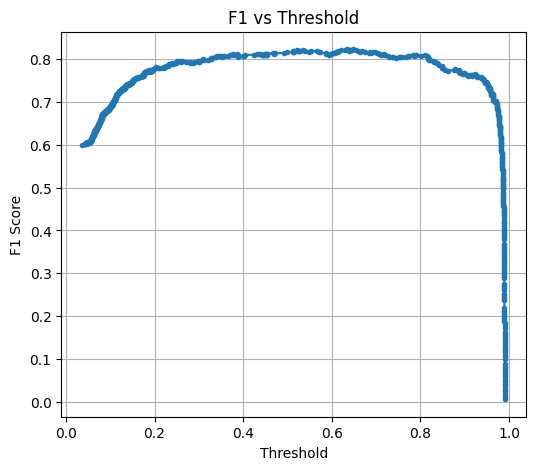

In [33]:
# ==============================================
# 7. 在验证集上调整分类阈值
# ==============================================

# 加载之前保存的最佳模型参数，确保使用性能最好的模型进行阈值调优
# 重新创建一个未经由于多gpu设置DataParallel包装的模型实例，结构与训练前相同
model = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
# 加载保存的最佳权重（保存时已去掉 module. 前缀）
model.load_state_dict(torch.load('best_model_state.bin'))
model.to(device)

# 推理阶段通常不需要再使用多卡，因此不包装 DataParallel
# 若坚持要用多卡推理，可在这里添加：
# if torch.cuda.device_count() > 1:
#     model = nn.DataParallel(model)

def get_predictions(model, data_loader, device):
    """
    获取模型在给定数据加载器上的预测概率和真实标签。
    注意：此函数不会传入 labels 给模型，因此模型只进行前向传播，不计算损失。

    参数:
        model: 训练好的最佳参数 BERT 分类模型
        data_loader: 包含数据的 DataLoader
        device: 设备（'cuda' 或 'cpu'）

    返回:
        all_probs: numpy 数组，形状 (样本数,)，每个元素是正类（灾难）的预测概率
        all_labels: numpy 数组，形状 (样本数,)，每个元素的真实标签
    """
    model.eval()  # 切换到评估模式（关闭 dropout 等）
    all_probs = []  # 存储所有样本的正类概率
    all_labels = [] # 存储所有样本的真实标签

    with torch.no_grad():  # 禁用梯度计算，节省内存和加速
        for batch in data_loader:
            # 将 batch 数据转移到设备
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # 前向传播，注意这里没有传入 labels，因此模型不会返回 loss
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # 获取原始输出分数，形状 (batch_size, 2)

            # 使用 softmax 将 logits 转换为概率，并取正类（索引为 1）的概率
            probs = torch.softmax(logits, dim=1)[:, 1]

            # 将张量转移到 CPU，转换为 numpy 数组后添加到列表中
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_probs), np.array(all_labels)

# 获取验证集的预测概率和真实标签
val_probs, val_labels = get_predictions(model, val_loader, device)

# ---- 寻找最佳分类阈值 ----
# precision_recall_curve 返回精确率、召回率和对应的阈值
# 注意：thresholds 的长度比 precision、recall 少 1（最后一个点没有对应阈值）
precision, recall, thresholds = precision_recall_curve(val_labels, val_probs)

# 计算每个阈值下的 F1 分数
# F1 = 2 * precision * recall / (precision + recall)
# 加入 1e-9 防止分母为零
f1_scores = 2 * precision * recall / (precision + recall + 1e-9)

# 找到 F1 分数最大的位置
best_idx = np.argmax(f1_scores)

# 获取最佳阈值和对应的 F1 分数
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f'Best threshold: {best_threshold:.4f}')
print(f'Best F1 on validation: {best_f1:.4f}')

# ---- 可视化 F1 与阈值的关系 ----
plt.figure(figsize=(6, 5))
# 注意：thresholds 的长度比 f1_scores 少 1，因此用 f1_scores[:-1] 与 thresholds 对应
plt.plot(thresholds, f1_scores[:-1], marker='.')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 vs Threshold')
plt.grid(True)
plt.show()

# **8-在测试集上预测并生成提交文件**

In [ ]:
# ==============================================
# 8. 在测试集上预测并生成提交文件
# ==============================================

# 获取测试集的文本
test_texts = test['text'].values

# 构建测试集的 Dataset
# 注意：测试集没有真实标签，因此 labels 全部用 0 占位（不会用于计算损失）
test_dataset = TweetDataset(test_texts, [0] * len(test_texts), tokenizer, MAX_LEN)

# 创建测试集的 DataLoader
# shuffle=False 确保顺序与原始数据一致，便于提交
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 获取测试集的预测概率（第二个返回值是占位标签，不需要使用）
test_probs, _ = get_predictions(model, test_loader, device)

# 应用在验证集上找到的最佳阈值，将概率转换为二分类预测（0 或 1）
test_preds = (test_probs >= best_threshold).astype(int)

# ---- 生成提交文件 ----
# 读取官方提供的样本提交文件，包含 id 列
submission = pd.read_csv('/kaggle/input/competitions/nlp-getting-started/sample_submission.csv')

# 将预测结果填入 target 列
submission['target'] = test_preds

# 保存提交文件
submission.to_csv('submission.csv', index=False)

print('Submission saved!')
print(submission['target'].value_counts())  # 查看预测为 0 和 1 的数量分布